# Black Hole Parameter Inference from EHT Observations

<div>
<img src="https://raw.githubusercontent.com/illinois-mlp/MachineLearningForPhysics/main/img/Project_EventHorizonTelescope.jpg" width=600></img>
</div>

## <span style="color:Orange">Background</span>

The [Event Horizon Telescope (EHT)](https://eventhorizontelescope.org/) is a global network of radio telescopes that uses [Very Long Baseline Interferometry (VLBI)](https://en.wikipedia.org/wiki/Very-long-baseline_interferometry) to achieve angular resolution sufficient to resolve the shadow of a supermassive black hole. In 2019, the EHT collaboration released the first image of the black hole shadow in Messier 87 (M87*) [[1](https://doi.org/10.3847/2041-8213/ab0ec7)], and in 2022, the first image of Sagittarius A* (Sgr A*), the black hole at the center of the Milky Way [[2](https://doi.org/10.3847/2041-8213/ac6674)].

The appearance of a black hole shadow depends on several physical parameters, including:
- **Black hole spin** $a$: the dimensionless angular momentum ($-1 \leq a \leq 1$), determining the asymmetry of the photon ring
- **Viewing inclination** $i$: the angle between the observer's line of sight and the black hole spin axis
- **Mass accretion rate** $\dot{M}$: controlling the overall brightness
- **Electron temperature prescription** $T_{e}$: a parameter governing how thermal energy is partitioned between ions and electrons in the accretion flow

To interpret EHT observations, researchers use computationally expensive [General Relativistic Magnetohydrodynamic (GRMHD)](https://en.wikipedia.org/wiki/Magnetohydrodynamics) simulations coupled with [General Relativistic Radiative Transfer (GRRT)](https://en.wikipedia.org/wiki/Radiative_transfer) codes to produce synthetic images of black hole shadows across a range of physical parameters [[3](https://doi.org/10.3847/2041-8213/ab0c57)]. Fitting these simulated images to observations allows estimation of the underlying black hole parameters.

Machine learning has emerged as a promising tool for this parameter estimation task, offering significant speedups over traditional MCMC-based pipelines [[4](https://doi.org/10.1051/0004-6361/201937014), [5](https://doi.org/10.1093/mnras/stad256)]. Recent work has demonstrated that convolutional neural networks can recover parameters such as mass and accretion rate from black hole shadow images, though spin recovery remains challenging at current EHT resolution [[4](https://doi.org/10.1051/0004-6361/201937014)].

Looking forward beyond this project, **Physics-Informed Neural Networks (PINNs)** [[6](https://doi.org/10.1016/j.jcp.2018.10.045)] offer the exciting possibility of embedding known physics (e.g., the Kerr metric, geodesic equations, radiative transfer) directly into the learning process, potentially improving parameter recovery with less training data and better physical consistency.

## <span style="color:Orange">Overview</span>

This notebook will have four goals:
1. Understanding the physics of black hole imaging and the EHT
2. Working with real EHT observational data using the `ehtim` library
3. Applying dimensionality reduction (PCA) to simulated black hole shadow images
4. Implementing a CNN to predict black hole parameters from shadow images

## <span style="color:Orange">Questions (Conceptual)</span>

### <span style="color:Green">Question 01</span>

What is the Event Horizon Telescope and how does interferometry allow a collection of telescopes to achieve the angular resolution of an Earth-sized dish? [[1](https://doi.org/10.3847/2041-8213/ab0ec7)]

In [8]:
# Your answer here

### <span style="color:Green">Question 02</span>

Briefly describe the key physical parameters that determine the appearance of a black hole shadow image (spin $a$, inclination $i$, mass accretion rate $\dot{M}$, electron temperature prescription $T_{e}$). Which of these do you expect to have the strongest visual signature in the image, and why?

In [9]:
# Your answer here

### <span style="color:Green">Question 03</span>

What is a GRMHD simulation, and why are large libraries of simulated images important for training ML models on black hole data? What are some limitations of relying on simulated training data when applying models to real EHT observations? [[3](https://doi.org/10.3847/2041-8213/ab0c57), [4](https://doi.org/10.1051/0004-6361/201937014)]

In [10]:
# Your answer here

## <span style="color:Orange">Data Sources</span>

We will work with two types of data in this project:

1. **Real EHT observations**: The publicly released Science Release 1 (SR1) visibility data from the 2017 EHT observation of M87* [[7](https://doi.org/10.3847/2041-8213/ab0c57)]. This data was used to produce the historic first image of a black hole. The data is in `uvfits` format, which is the standard for VLBI data, and contains complex visibilities measured on baselines between telescope pairs.

2. **Simulated observations**: Using the `ehtim` library [[8](https://github.com/achael/eht-imaging)], we will generate synthetic observations of parameterized black hole models with the same $(u,v)$ coverage as the real EHT array. This gives us labeled training data where the ground truth parameters are known.

The `ehtim` (eht-imaging) library is the primary open-source Python package developed by the EHT collaboration for loading, simulating, and imaging VLBI data. It was one of the three imaging pipelines used to produce the published M87* image [[9](https://doi.org/10.3847/2041-8213/ab0e85)].

### Installing ehtim and Downloading Data

In [11]:
# Install ehtim
!pip install ehtim -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.0/445.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 10.4 MB/s eta 0:00:00


In [12]:
# Clone the EHT SR1 public data release
import os
if not os.path.exists('2019-D01-01'):
    !git clone --depth 1 https://github.com/eventhorizontelescope/2019-D01-01.git
print("EHT SR1 data files:")
for f in sorted(os.listdir('2019-D01-01/uvfits')):
    if f.endswith('.uvfits'):
        print(f"  {f}")

Cloning into '2019-D01-01'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 39 (delta 2), reused 39 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 8.67 MiB | 18.38 MiB/s, done.
Resolving deltas: 100% (2/2), done.
EHT SR1 data files:
  SR1_M87_2017_095_hi_hops_netcal_StokesI.uvfits
  SR1_M87_2017_095_lo_hops_netcal_StokesI.uvfits
  SR1_M87_2017_096_hi_hops_netcal_StokesI.uvfits
  SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits
  SR1_M87_2017_100_hi_hops_netcal_StokesI.uvfits
  SR1_M87_2017_100_lo_hops_netcal_StokesI.uvfits
  SR1_M87_2017_101_hi_hops_netcal_StokesI.uvfits
  SR1_M87_2017_101_lo_hops_netcal_StokesI.uvfits


The SR1 data release contains calibrated Stokes I visibilities for M87* from four observing days in April 2017 (April 5, 6, 10, 11 — corresponding to day-of-year 095, 096, 100, 101), each with a low-band and high-band frequency channel at ~227 GHz. These are the exact data used in the original EHT M87 publications.

### Loading and Exploring the Real EHT Data

In this section we show one way to load and explore data from ehtim's official tutorial. This is a standard way of using ehtim. You can find those tutorials [here](https://github.com/achael/eht-imaging/tree/main/tutorials).

In [13]:
import ehtim as eh
import numpy as np
import matplotlib.pyplot as plt

# Load a single observation day (April 6, 2017 — day 096, low band)
obs = eh.obsdata.load_uvfits('2019-D01-01/uvfits/SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits')

print(f"Source: {obs.source}")
print(f"Frequency: {obs.rf/1e9:.2f} GHz")
print(f"MJD: {obs.mjd}")
print(f"Number of visibilities: {len(obs.data)}")
print(f"Telescopes: {obs.tarr['site']}")

Welcome to eht-imaging! v 1.2.10 

Loading uvfits:  2019-D01-01/uvfits/SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Source: M87
Frequency: 227.07 GHz
MJD: 57849
Number of visibilities: 8645
Telescopes: ['AA' 'AP' 'AZ' 'JC' 'LM' 'PV' 'SM' 'SR']


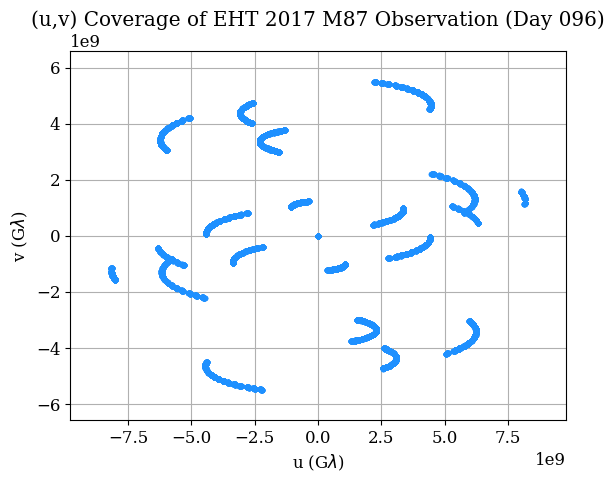

In [14]:
# Plot the (u,v) coverage — this shows the Fourier plane sampling
# Each point represents a baseline measurement between two telescopes
# The gaps in coverage are why image reconstruction is challenging

obs.plotall('u','v', conj=True, show=False, export_pdf='')
plt.title('(u,v) Coverage of EHT 2017 M87 Observation (Day 096)')
plt.xlabel(r'u (G$\lambda$)')
plt.ylabel(r'v (G$\lambda$)')
plt.show()

### <span style="color:Green">Question 04</span>

Referring to the previous example, plot the **visibility amplitudes** as a function of **uv-distance** for the loaded
EHT observation (hint: look at `obs.plotall()`).
What structure do you notice, and what does it tell you about the source morphology?

In [15]:
# Your code here

### <span style="color:Green">Question 05</span>

Construct a **dirty image** and **dirty beam** (PSF) from the real M87* data
using `obs.dirtyimage()` and `obs.dirtybeam()` with `npix=64` and a field of view
of 200 $\mu$as (`fov = 200 * eh.RADPERUAS`). Plot them side by side.
What does the dirty beam tell you about the EHT's resolving power and sidelobe structure? You should find the tutorials linked previously helpful.

In [16]:
# Your code here

## <span style="color:Orange">Generating Labeled Training Data</span>

To train a machine learning model, we need labeled data — images with known physical parameters. Since the real EHT data has only one target (M87*) with uncertain parameters, we generate synthetic training data using `ehtim`'s model and simulation capabilities.

The approach:
1. Create parameterized black hole shadow models (crescents with varying parameters)
2. "Observe" each model with the same $(u,v)$ coverage as the real EHT array
3. Reconstruct images from the simulated visibilities using `ehtim`'s dirty imaging

This mirrors the approach used in production EHT analysis, where GRMHD simulation images are forward-modeled through the EHT observation pipeline to create synthetic data for comparison [[3](https://doi.org/10.3847/2041-8213/ab0c57)].

We parameterize our simple model with:
- **Crescent asymmetry** $\xi \in [0.01, 0.99]$: controls brightness asymmetry (proxy for spin + inclination Doppler beaming)
- **Ring diameter** $d \in [30, 60]$ $\mu$as: related to black hole mass through the shadow radius $\theta \approx 5.2 \, GM/c^2 D$
- **Position angle** $\phi \in [0°, 360°]$: orientation of the crescent on the sky
- **Total flux** $F \in [0.3, 1.5]$ Jy: overall brightness (proxy for accretion rate)

While this simplified model does not capture the full complexity of GRMHD simulations, it produces realistic-looking images suitable for demonstrating ML parameter inference and is the same class of geometric model used in early EHT parameter estimation [[9](https://doi.org/10.3847/2041-8213/ab0e85)].

In [17]:
# Generate a dataset of simulated observations
# Uses FFT convolution with the real EHT dirty beam (PSF) for speed

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
N_samples = 2000
npix = 64
fov = 200 * eh.RADPERUAS

# Load real EHT observation to get (u,v) coverage
obs_template = eh.obsdata.load_uvfits(
    '2019-D01-01/uvfits/SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits'
)

# Precompute dirty beam (PSF) from real (u,v) coverage
dbeam = obs_template.dirtybeam(npix, fov)
psf = dbeam.imvec.reshape(npix, npix)
psf_fft = np.fft.fft2(np.fft.ifftshift(psf))

# Noise estimate from real observation uncertainties
noise_level = np.median(obs_template.data['sigma']) / np.sqrt(len(obs_template.data)) * 3

# Parameter ranges
asymmetries = np.random.uniform(0.01, 0.99, N_samples)
diameters = np.random.uniform(30, 60, N_samples)        # in microarcseconds
pos_angles = np.random.uniform(0, 360, N_samples)        # in degrees
fluxes = np.random.uniform(0.3, 1.5, N_samples)          # in Jy

images = np.zeros((N_samples, npix, npix), dtype=np.float32)

for idx in range(N_samples):
    if idx % 500 == 0:
        print(f"Generating sample {idx}/{N_samples}...")

    # Create crescent model using ehtim
    im = eh.image.make_square(obs_template, npix, fov)
    Rp = diameters[idx] * eh.RADPERUAS / 2.0
    Rn = Rp * (1 - asymmetries[idx] * 0.5)
    offset_x = Rp * asymmetries[idx] * 0.3 * np.cos(np.radians(pos_angles[idx]))
    offset_y = Rp * asymmetries[idx] * 0.3 * np.sin(np.radians(pos_angles[idx]))
    im = im.add_crescent(fluxes[idx], Rp, Rn, offset_x, offset_y)
    model = im.imvec.reshape(npix, npix)

    # Simulate dirty image: convolve model with real EHT PSF via FFT
    dirty = np.real(np.fft.ifft2(np.fft.fft2(model) * psf_fft))
    dirty = np.nan_to_num(dirty, nan=0.0)

    # Add observational noise
    dirty += noise_level * np.random.randn(npix, npix)
    images[idx] = dirty.astype(np.float32)

print(f"\nDataset generated: {images.shape}")
print(f"Asymmetry range: [{asymmetries.min():.2f}, {asymmetries.max():.2f}]")
print(f"Diameter range: [{diameters.min():.1f}, {diameters.max():.1f}] uas")
print(f"Position angle range: [{pos_angles.min():.1f}, {pos_angles.max():.1f}] deg")
print(f"Flux range: [{fluxes.min():.2f}, {fluxes.max():.2f}] Jy")

Loading uvfits:  2019-D01-01/uvfits/SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Generating sample 0/2000...
Generating sample 500/2000...
Generating sample 1000/2000...
Generating sample 1500/2000...

Dataset generated: (2000, 64, 64)
Asymmetry range: [0.01, 0.99]
Diameter range: [30.0, 60.0] uas
Position angle range: [0.0, 359.8] deg
Flux range: [0.30, 1.50] Jy


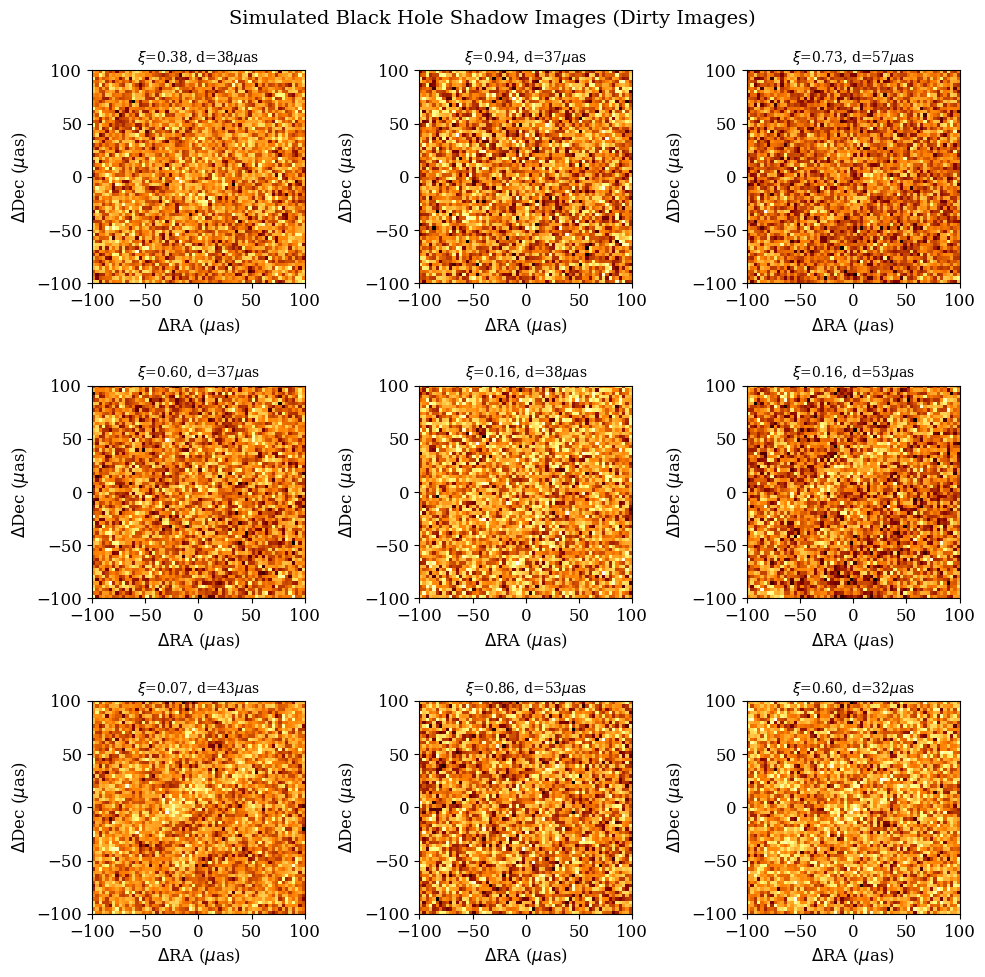

In [18]:
# Visualize a few simulated images
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
extent = [-fov/eh.RADPERUAS/2, fov/eh.RADPERUAS/2,
          -fov/eh.RADPERUAS/2, fov/eh.RADPERUAS/2]

for idx, ax in enumerate(axes.flat):
    ax.imshow(images[idx], cmap='afmhot', origin='lower', extent=extent)
    ax.set_title(f'$\\xi$={asymmetries[idx]:.2f}, d={diameters[idx]:.0f}$\\mu$as',
                 fontsize=10)
    ax.set_xlabel(r'$\Delta$RA ($\mu$as)')
    ax.set_ylabel(r'$\Delta$Dec ($\mu$as)')

plt.suptitle('Simulated Black Hole Shadow Images (Dirty Images)', fontsize=14)
plt.tight_layout()
plt.show()

## <span style="color:Orange">Dimensionality Reduction</span>

Principal Component Analysis (PCA) is a useful tool for understanding the dominant modes of variation in high-dimensional data. For images, PCA finds the directions in pixel space that capture the most variance. Each principal component can be reshaped back into an image and interpreted as an "eigenimage", a pattern of variation across the dataset.

This technique has direct relevance to EHT science: the PRIMO algorithm [[10](https://doi.org/10.3847/2041-8213/acc32d)] that produced the sharpened M87* image is fundamentally a PCA-based method. It learns a basis of principal components from a training set of GRMHD images and uses them to reconstruct the observed data at higher fidelity.

## <span style="color:Orange">Questions (Dimensionality Reduction)</span>

### <span style="color:Green">Question 06</span>

Perform PCA on the flattened image dataset (each image reshaped to a 1D vector).
Center the data by subtracting the mean image before fitting.
Plot the explained variance ratio as a function of the number of components —
how many components are needed to capture 90% of the total variance?
Visualize the first several principal components reshaped back into images.

In [19]:
# Your code here
# from sklearn.decomposition import PCA # Helpful PCA library

## <span style="color:Orange">CNN for Black Hole Parameter Prediction</span>

From the previous PCA analyses you most likely concluded that noise is dominating the signal, which motivates us to move from linear methods to nonlinear ones. Convolutional neural networks are a natural choice for extracting information from images, and have been applied to black hole shadow parameter estimation in several studies. Some notable approaches include:

- **Deep Horizon** [[4](https://doi.org/10.1051/0004-6361/201937014)]: Used a Bayesian deep CNN for regression of viewing angle, accretion rate, and mass, plus a classification network for spin recovery
- **PRIMO** [[10](https://doi.org/10.3847/2041-8213/acc32d)]: A PCA-based ML method that improved the resolution of the M87* image by filling in gaps in the Fourier coverage
- **Random forest on polarimetric observables** [[5](https://doi.org/10.1093/mnras/stad256)]: Used hand-crafted polarimetric features with random forests for parameter inference
- **VLBInet** [[11](https://doi.org/10.3847/2041-8213/ac2b3b)]: Neural networks applied directly to visibility-domain data for classifying accretion state (MAD vs SANE)

## <span style="color:Orange">Questions (CNN Prediction)</span>

### <span style="color:Green">Question 07</span>

Design and implement a convolutional neural network to predict the crescent
**diameter** $d$ (in $\mu$as) from the simulated dirty images. Use an 80/20 train/test split.
Report the test MSE, plot **predicted vs. true** diameter for the test set,
and show the **training loss curve** over epochs.

As a follow-up: use your trained CNN to predict the diameter from the **real M87* dirty image**
you constructed in Question 05.
The EHT collaboration found M87* is well described by a crescent with diameter
$\sim 40.9 \pm 2.4$ $\mu$as [[9](https://doi.org/10.3847/2041-8213/ab0e85)].
How does your CNN's prediction compare? Discuss possible reasons for any discrepancy
(e.g., domain gap between simple crescent models and real data,
noise properties, features not captured by the geometric model).

In [20]:
# Your code here
# Some helpful libraries
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset

## <span style="color:Orange">Questions (Overview / Summary)</span>

### <span style="color:Green">Question 08</span>

Your CNN was trained purely on data — it has no knowledge of general relativity,
radiative transfer, or the Kerr metric. Yet it predicted M87*'s diameter within
a few $\mu$as of the published value.

Write a short paragraph on:
- What physical knowledge is "baked into" your training pipeline even though the
  CNN itself doesn't know any physics? (Think about how the training data was generated.)
- What limitations might this approach have if applied to a more complex task,
  such as predicting black hole spin (which has a subtler visual signature) from GRMHD simulation images instead of
  diameter from simple crescents?
- If you could add a physics-based penalty term to the loss function, for example,
  enforcing that the predicted diameter must be consistent with the shadow radius
  predicted by the Kerr metric (which describes how a spinning black hole distorts surrounding spacetime), how might that
  improve or constrain the network's predictions?

In [21]:
# Your answer here

## <span style="color:Orange">References</span>

__[<span style="color:Blue">1</span>]__ Event Horizon Telescope Collaboration et al. (2019). First M87 Event Horizon Telescope Results. I. The Shadow of the Supermassive Black Hole. *The Astrophysical Journal Letters*, 875(1), L1. https://doi.org/10.3847/2041-8213/ab0ec7 <br>

__[<span style="color:Blue">2</span>]__ Event Horizon Telescope Collaboration et al. (2022). First Sagittarius A* Event Horizon Telescope Results. I. The Shadow of the Supermassive Black Hole in the Center of the Milky Way. *The Astrophysical Journal Letters*, 930(2), L12. https://doi.org/10.3847/2041-8213/ac6674 <br>

__[<span style="color:Blue">3</span>]__ Event Horizon Telescope Collaboration et al. (2019). First M87 Event Horizon Telescope Results. V. Physical Origin of the Asymmetric Ring. *The Astrophysical Journal Letters*, 875(1), L5. https://doi.org/10.3847/2041-8213/ab0f43 <br>

__[<span style="color:Blue">4</span>]__ van der Gucht, J., Davelaar, J., Hendriks, L., et al. (2020). Deep Horizon: A machine learning network that recovers accreting black hole parameters. *Astronomy & Astrophysics*, 636, A94. https://doi.org/10.1051/0004-6361/201937014 <br>

__[<span style="color:Blue">5</span>]__ Ricarte, A., Tiede, P., Emami, R., Taber, A., & Natarajan, P. (2023). Using Machine Learning to link black hole accretion flows with spatially resolved polarimetric observables. *Monthly Notices of the Royal Astronomical Society*, 520(4), 4867–4888. https://doi.org/10.1093/mnras/stad466

__[<span style="color:Blue">6</span>]__ Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. *Journal of Computational Physics*, 378, 686–707. https://doi.org/10.1016/j.jcp.2018.10.045 <br>

__[<span style="color:Blue">7</span>]__ Event Horizon Telescope Collaboration et al. (2019). First M87 Event Horizon Telescope Results. III. Data Processing and Calibration. *The Astrophysical Journal Letters*, 875(1), L3. https://doi.org/10.3847/2041-8213/ab0c57 <br>

__[<span style="color:Blue">8</span>]__ Chael, A. A., Johnson, M. D., Narayan, R., et al. (2016). High-resolution Linear Polarimetric Imaging for the Event Horizon Telescope. *The Astrophysical Journal*, 829(1), 11. https://doi.org/10.3847/0004-637X/829/1/11 <br>

__[<span style="color:Blue">9</span>]__ Event Horizon Telescope Collaboration et al. (2019). First M87 Event Horizon Telescope Results. IV. Imaging the Central Supermassive Black Hole. *The Astrophysical Journal Letters*, 875(1), L4. https://doi.org/10.3847/2041-8213/ab0e85 <br>

__[<span style="color:Blue">10</span>]__ Medeiros, L., Psaltis, D., Lauer, T. R., & Özel, F. (2023). The Image of the M87 Black Hole Reconstructed with PRIMO. *The Astrophysical Journal Letters*, 947(1), L7. https://doi.org/10.3847/2041-8213/acc32d <br>

__[<span style="color:Blue">11</span>]__ Lin, Y.-Y., Pesce, D. W., Wong, G. N., et al. (2021). VLBInet: Radio Interferometry Data Classification for EHT with Neural Networks. *The Astrophysical Journal Letters*, 921(1), L2. https://doi.org/10.48550/arXiv.2110.07185 <br>

__[<span style="color:Blue">12</span>]__ Smith, L., et al. (2025). PINNGraPE: Physics Informed Neural Network for Gravitational wave Parameter Estimation. *arXiv preprint arXiv:2510.02858*. https://doi.org/10.48550/arXiv.2510.02858

## <span style="color:Orange">Acknowledgements</span>

* Initial version: Yuheng Guo with some guidence from Mark Neubauer
* EHT SR1 data: [Event Horizon Telescope Collaboration](https://eventhorizontelescope.org/), data release [2019-D01-01](https://github.com/eventhorizontelescope/2019-D01-01)
* eht-imaging library: [Andrew Chael et al.](https://github.com/achael/eht-imaging)